# **Data Preprocessing and Automated Labeling Pipeline**

Notebook này thiết lập nền tảng dữ liệu cho hệ thống phân tích cảm xúc đa phương thức. Trọng tâm của tài liệu bao gồm việc kiểm định chất lượng dữ liệu thô, làm sạch, chuẩn hóa văn bản tiếng Việt và đánh giá tác động của các kỹ thuật tiền xử lý trước khi tiến hành trích xuất đặc trưng.

---

## **1. Environment Setup**

Phân hệ này khởi tạo môi trường làm việc, nạp các thư viện toán học và xử lý dữ liệu lõi nhằm đảm bảo tính nhất quán và khả năng tái lập của toàn bộ quy trình.

### 1.1. Import Libraries

Khai báo các thư viện tiêu chuẩn để tính toán ma trận, thao tác dữ liệu bảng và băm chuỗi ký tự phục vụ việc nhận diện bản ghi trùng lặp.

In [1]:
import hashlib
import io
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd

from pandarallel import pandarallel
from ai_engine.text_processing.preprocessor import TextCleaner

import matplotlib.pyplot as plt
import seaborn as sns

### 1.2. Load Dataset

Nạp tập dữ liệu đánh giá sản phẩm thô vào bộ nhớ. Đây là nguồn dữ liệu chuẩn để thực hiện mọi bước kiểm định và tiền xử lý tiếp theo.

In [2]:
DATA_PATH = "../data/raw/all_reviews.csv"
df = pd.read_csv(DATA_PATH)

display(df.head())

,product_name,text,rating,date,image_urls,product_url,scraped_at
0,Sách Thầm Yêu Ánh Dương Rực Rỡ,Đọc quá trời hay luôn á 5⭐️ Kh có ảnh nên lấy đại,5,2026-04-24,https://salt.tikicdn.com/ts/review/b0/35/30/e5...,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380507
1,Sách Thầm Yêu Ánh Dương Rực Rỡ,"Hay nha, sẽ ủng hộ dài dài, đóng gói oki",5,2026-04-21,https://salt.tikicdn.com/ts/review/3b/db/ac/ee...,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380617
2,Sách Thầm Yêu Ánh Dương Rực Rỡ,NaN,5,2026-04-18,NaN,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380634
3,Sách Thầm Yêu Ánh Dương Rực Rỡ,NaN,5,2026-04-03,NaN,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380658
4,Sách Thầm Yêu Ánh Dương Rực Rỡ,"Nội dung gần gũi, sách đẹp, giao hàng nhanh, đ...",5,2026-03-12,NaN,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380672


## **2. Data Quality Assurance and Initial EDA**

Quy trình kiểm định chất lượng dữ liệu giúp nhận diện các bất thường phát sinh từ thao tác thu thập. Việc làm sạch sớm giúp ngăn chặn nhiễu lan truyền sang các mô hình học máy ở giai đoạn sau.

### 2.1. Basic Descriptive Statistics

Khảo sát quy mô tập dữ liệu, cấu trúc cột và thống kê mô tả cơ bản để đánh giá mức độ khuyết thiếu thông tin. Phân tích này là cơ sở để ra quyết định điền khuyết hoặc loại bỏ mẫu.

In [3]:
num_rows, num_cols = df.shape
print(f"Number of records: {num_rows:,}")
print(f"Number of features: {num_cols}")

Number of records: 9,386
Number of features: 7


In [4]:
# Display schema: data types & non-null counts
print("Dataset schema overview:")
df.info()

Dataset schema overview:
<class 'pandas.DataFrame'>
RangeIndex: 9386 entries, 0 to 9385
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_name  9386 non-null   str  
 1   text          6193 non-null   str  
 2   rating        9386 non-null   int64
 3   date          9338 non-null   str  
 4   image_urls    3916 non-null   str  
 5   product_url   9386 non-null   str  
 6   scraped_at    9386 non-null   str  
dtypes: int64(1), str(6)
memory usage: 513.4 KB


In [5]:
# Target Variable Analysis
print("Descriptive statistics for 'rating':")
print(df["rating"].describe())

Descriptive statistics for 'rating':
count    9386.000000
mean        4.848604
std         0.580253
min         1.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: rating, dtype: float64


In [6]:
# Missing Value Analysis
missing_rate = df.isnull().mean().mul(100).sort_values(ascending=False)
print("Missing value percentage by column (%):")
print(missing_rate)

Missing value percentage by column (%):
image_urls      58.278287
text            34.018751
date             0.511400
rating           0.000000
product_name     0.000000
product_url      0.000000
scraped_at       0.000000
dtype: float64


**Nhận xét:** Các trường dữ liệu văn bản và liên kết hình ảnh như `image_urls` hoặc `text` thường có tỷ lệ thiếu cao do review không kèm ảnh hoặc rỗng nội dung. Đây là đặc thù của dữ liệu thương mại điện tử khi người dùng chỉ để lại điểm số mà không đính kèm nội dung chi tiết. Các bản ghi này cần được xử lý trước khi đưa vào mô hình ngôn ngữ.

### 2.2. Anomaly Detection and Handling

Quá trình cào dữ liệu thường sinh ra các bản ghi trùng lặp cơ học hoặc thu thập phải các bình luận không mang giá trị thông tin ngữ nghĩa.

#### 2.2.1. Handling Duplicates

Thuật toán băm MD5 được áp dụng lên nội dung đánh giá để ánh xạ các chuỗi văn bản dài thành các mã định danh duy nhất. Phương pháp này tối ưu hóa tốc độ tìm kiếm và loại bỏ các bản sao chính xác tuyệt đối giữa các nền tảng khác nhau.

In [7]:
initial_record_count = len(df)

# Generate MD5 hash for text content to identify duplicates
df["text_hash"] = df["text"].apply(
    lambda x: hashlib.md5(str(x).encode("utf-8")).hexdigest()
    if pd.notnull(x)
    else np.nan
)

# Remove duplicate records based on hashed text
df = (
    df.drop_duplicates(subset=["text_hash"])
      .drop(columns=["text_hash"])
)

removed_duplicates = initial_record_count - len(df)

print(f"Removed duplicate records: {removed_duplicates:,}")
print(f"Remaining records: {len(df):,}")

Removed duplicate records: 4,611
Remaining records: 4,775


#### 2.2.2. Handling Missing Values and Noise

Các đánh giá chỉ chứa ký tự khoảng trắng hoặc có độ dài vật lý quá ngắn không chứa đủ đặc trưng ngữ nghĩa cho mô hình học sâu. Việc thanh lọc các mẫu này giúp giảm thiểu hiện tượng nhiễu và tối ưu hóa không gian vector nhúng sau này.

In [8]:
pre_cleaning_count = len(df)

# Convert empty or whitespace-only strings to NaN
df["text"] = df["text"].replace(r"^\s*$", np.nan, regex=True)

# Remove records with missing text
df = df.dropna(subset=["text"])

# Filter out extremely short comments (length <= 2)
df = df[df["text"].str.len() > 2]

post_cleaning_count = len(df)
removed_noise = pre_cleaning_count - post_cleaning_count

print(f"Removed noisy records: {removed_noise:,}")
print(f"Final dataset size: {post_cleaning_count:,}")

Removed noisy records: 40
Final dataset size: 4,735


### 2.3. Consistency Checks

Việc đồng bộ hóa kiểu dữ liệu và định dạng vật lý đảm bảo các thao tác tính toán ma trận và thống kê không bị gián đoạn bởi các ngoại lệ lập trình.

In [9]:
df = df.copy()

# Convert 'date' column to datetime format
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Convert rating to numeric, handle invalid values
df["rating"] = pd.to_numeric(df["rating"], errors="coerce").fillna(0).astype(int)
df = df[df["rating"].between(1, 5)]

# Trim leading/trailing whitespace from text
df["text"] = df["text"].str.strip()

print("Preview of cleaned dataset:")
display(df.head())

Preview of cleaned dataset:


,product_name,text,rating,date,image_urls,product_url,scraped_at
0,Sách Thầm Yêu Ánh Dương Rực Rỡ,Đọc quá trời hay luôn á 5⭐️ Kh có ảnh nên lấy đại,5,2026-04-24,https://salt.tikicdn.com/ts/review/b0/35/30/e5...,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380507
1,Sách Thầm Yêu Ánh Dương Rực Rỡ,"Hay nha, sẽ ủng hộ dài dài, đóng gói oki",5,2026-04-21,https://salt.tikicdn.com/ts/review/3b/db/ac/ee...,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380617
4,Sách Thầm Yêu Ánh Dương Rực Rỡ,"Nội dung gần gũi, sách đẹp, giao hàng nhanh, đ...",5,2026-03-12,NaN,https://tiki.vn/dien-thoai-samsung-galaxy-a36-...,2026-04-29T23:49:44.380672
8,Son dưỡng môi hiệu chỉnh ửng hồng tự nhiên Lip...,"Date xa , tui rất thích .Cả 3 loại dòng LipIce...",5,2026-02-05,NaN,https://tiki.vn/dien-thoai-xiaomi-redmi-15-8gb...,2026-04-29T23:49:46.216605
9,Son dưỡng môi hiệu chỉnh ửng hồng tự nhiên Lip...,Điện thoại đag bị hư k up ảnh sản phẩm đc 🤭 nh...,5,2026-02-05,NaN,https://tiki.vn/dien-thoai-xiaomi-redmi-15-8gb...,2026-04-29T23:49:46.216621


**Tổng kết phân hệ đảm bảo chất lượng:** Quy trình đã thành công thiết lập một tập dữ liệu chuẩn về mặt cấu trúc. Hệ thống đã loại bỏ triệt để các nhiễu sinh ra từ quá trình thu thập, tạo tiền đề vững chắc cho các kỹ thuật xử lý ngôn ngữ tự nhiên phức tạp ở các phân hệ kế tiếp.

## **3. Text Normalization Pipeline & Impact Analysis**

Phân hệ này khởi tạo và áp dụng quy trình chuẩn hóa văn bản tiếng Việt từ nguồn đánh giá thương mại điện tử. Quá trình bao gồm việc chuyển đổi chữ thường, loại bỏ thẻ định dạng trang web, lọc bỏ ký tự đặc biệt không mang thông tin ngữ nghĩa, và đồng nhất hóa các mã ngôn ngữ mạng cũng như từ lóng. Việc chuẩn hóa giúp giảm thiểu độ nhiễu vật lý và cho phép định lượng chặt chẽ tác động của các kỹ thuật làm sạch đối với không gian đặc trưng phân phối của tập ngữ liệu.

### 3.1. Normalization Execution

Quá trình thực thi sử dụng thuật toán làm sạch được thiết kế và tối ưu từ mô đun tiền xử lý cốt lõi của hệ thống. Để đảm bảo hiệu năng trên tập dữ liệu quy mô lớn, phương pháp lập trình song song qua đa luồng được áp dụng. Phương pháp này giúp tăng tốc độ tiền xử lý đáng kể so với vòng lặp tuần tự và đảm bảo tính tất định xuyên suốt các bước thực nghiệm học máy.

In [10]:
# Initialize parallel processing with a visual progress indicator
pandarallel.initialize(progress_bar=True)

# Instantiate the stateless text cleaning pipeline
cleaner = TextCleaner()

# Execute multi-threaded text normalization
df['cleaned_text'] = df['text'].parallel_apply(cleaner.clean_text)

# Convert whitespace-only strings to NaN and remove null records
df['cleaned_text'] = df['cleaned_text'].replace(r"^\s*$", np.nan, regex=True)
df = df.dropna(subset=['cleaned_text'])

# Display a comparative view of raw versus normalized text
display(df[['text', 'cleaned_text']].head())

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


,text,cleaned_text
0,Đọc quá trời hay luôn á 5⭐️ Kh có ảnh nên lấy đại,đọc quá trời hay luôn á 5 star không có ảnh nê...
1,"Hay nha, sẽ ủng hộ dài dài, đóng gói oki","hay nha , sẽ ủng_hộ dài_dài , đóng_gói tốt"
4,"Nội dung gần gũi, sách đẹp, giao hàng nhanh, đ...","nội_dung gần_gũi , sách_đẹp , giao hàng nhanh ..."
8,"Date xa , tui rất thích .Cả 3 loại dòng LipIce...","hạn sử_dụng xa , tui rất thích . cả 3 loại dòn..."
9,Điện thoại đag bị hư k up ảnh sản phẩm đc 🤭 nh...,điện_thoại đag bị hư không up_ảnh sản_phẩm đượ...


### 3.2. Normalization Impact Assessment

Định lượng tác động của bước chuẩn hóa là yêu cầu thiết yếu để đánh giá tính hợp lý và hiệu quả của toàn bộ quy trình. Phân hệ này đo lường độ nén từ vựng thông qua tỷ lệ suy giảm số lượng đơn vị từ độc lập do hợp nhất các lỗi gõ với từ chuẩn mực và phân tích sự dịch chuyển phân phối độ dài văn bản. Khảo sát này minh chứng cho việc quá trình làm sạch tăng cường độ cô đọng mà không làm mất đi các thành tố ngữ nghĩa quan trọng.

Vocabulary Size Before: 6,659 tokens
Vocabulary Size After:  4,987 tokens
Vocabulary Reduction:   25.11%



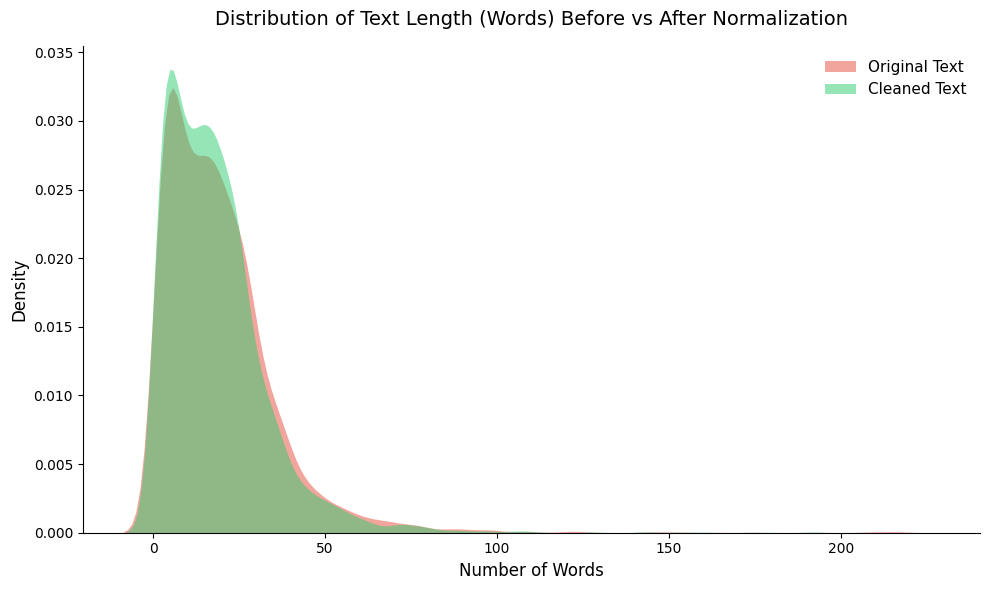

In [11]:
# Compute total unique tokens before and after normalization using set operations
tokens_before = set(" ".join(df['text'].astype(str)).split())
tokens_after = set(" ".join(df['cleaned_text'].astype(str)).split())

vocab_before = len(tokens_before)
vocab_after = len(tokens_after)
reduction_pct = (vocab_before - vocab_after) / vocab_before * 100

print(f"Vocabulary Size Before: {vocab_before:,} tokens")
print(f"Vocabulary Size After:  {vocab_after:,} tokens")
print(f"Vocabulary Reduction:   {reduction_pct:.2f}%\n")

# Calculate text length in terms of word count
df['len_before'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df['len_after'] = df['cleaned_text'].astype(str).apply(lambda x: len(x.split()))

# Visualize text length distributions utilizing Gestalt design principles
plt.figure(figsize=(10, 6))

# Apply Contrast & Similarity principles to differentiate overlapping data
sns.kdeplot(df['len_before'], fill=True, color="#E74C3C", label="Original Text", alpha=0.5, linewidth=0)
sns.kdeplot(df['len_after'], fill=True, color="#2ECC71", label="Cleaned Text", alpha=0.5, linewidth=0)

# Standardize academic axis labels and title typography
plt.title("Distribution of Text Length (Words) Before vs After Normalization", fontsize=14, pad=15)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Apply Figure-Ground principle by removing distracting chart borders
sns.despine(top=True, right=True, left=False, bottom=False)

# Apply Proximity principle to align the legend logically
plt.legend(frameon=False, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

**Nhận xét:** Biểu đồ ước lượng mật độ nhân cùng chỉ số thống kê minh chứng cho sự co lại mạnh mẽ của không gian từ vựng tổng thể. Việc hợp nhất các yếu tố nhiễu về dạng chuẩn giúp giảm độ phân tán của độ dài văn bản thông qua việc thu hẹp phần đuôi phân phối dài chứa các ký tự lặp vô nghĩa. Sự tinh gọn không gian từ vựng một cách có chủ đích mang lại lợi ích lớn trong việc giảm thiểu đáng kể tần suất xuất hiện của từ ngữ ngoài từ điển khi cấy ghép vào các mô hình học sâu. Mật độ ngữ nghĩa cao trên một tập từ vựng tối ưu giúp các kiến trúc mạng nơ ron sâu hội tụ nhanh hơn và truy xuất được tọa độ biểu diễn vector chính xác.

## 4. Vietnamese Tokenization Strategy Comparison

This section evaluates tokenization strategies tailored to Vietnamese, where standard English tokenizers are suboptimal.

**4.1. Strategy Implementation**
- Syllable-level tokenization (whitespace baseline).
- Word-level tokenization using `underthesea` or `VnCoreNLP`.
- Subword-level tokenization using BPE from `vinai/phobert-base`.

**4.2. Quantitative Reporting**
- Compare methods by vocabulary size, OOV rate, and average token sequence length.
- Conclude with a data-driven justification for the selected strategy.

## 5. Stopword Filtering & Information Theoretic Analysis

This section evaluates the impact of stopword removal on sentiment signal retention.

**5.1. Stopword Application**
- Apply a curated Vietnamese stopword list (`VI_STOPWORDS`).
- Track the proportion of tokens removed and the resulting vocabulary shift.

**5.2. Quantitative & Contextual Analysis**
- Compute Mutual Information (MI) between terms and star ratings before vs. after stopword removal.
- Train a Naive Bayes baseline to assess whether removing function words harms sentiment cues.
- Discuss linguistic nuances such as the negation term "không", which may be high-frequency yet sentiment-critical.

## 6. Automated Weak Supervision Labeling Pipeline

This section constructs weakly supervised labels to enable downstream modeling at scale.

**6.1. Rule-based & Lexicon Heuristics**
- Bootstrap sentiment and aspect labels using domain-specific lexicons and heuristics.
- Define deterministic rules for high-confidence cases (e.g., rating-aligned sentiment).

**6.2. LLM Fallback Mechanism**
- Route ambiguous or highly contextual reviews to the LLM client (e.g., Gemini) for resolution.
- Log fallback frequency and rationale to quantify reliance on LLM-based labeling.

**6.3. Artifact Export**
- Persist the curated dataset as `processed_labeled_reviews.csv` for the modeling notebook.
- Record metadata (timestamp, preprocessing config, labeling rules) to ensure traceability.